### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [2]:
# lee el archivo .tsv en un dataframe

import pandas as pd

df = pd.read_csv("drugLibTrain_raw.tsv", sep="\t")

In [3]:
df

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...,...
3102,1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3103,3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
3104,1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
3105,2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categoricas con pocas categorias (10 como mucho)

In [5]:
# selecciona solo las columnas que cumplan ese criterio


cols_validas = []

for c in df.columns:

    if df[c].dtype != "object":
        cols_validas.append(c)

    elif df[c].nunique() <= 10:
        cols_validas.append(c)

df = df[cols_validas]


In [9]:
df_graficas = df[["rating", "effectiveness", "sideEffects"]]

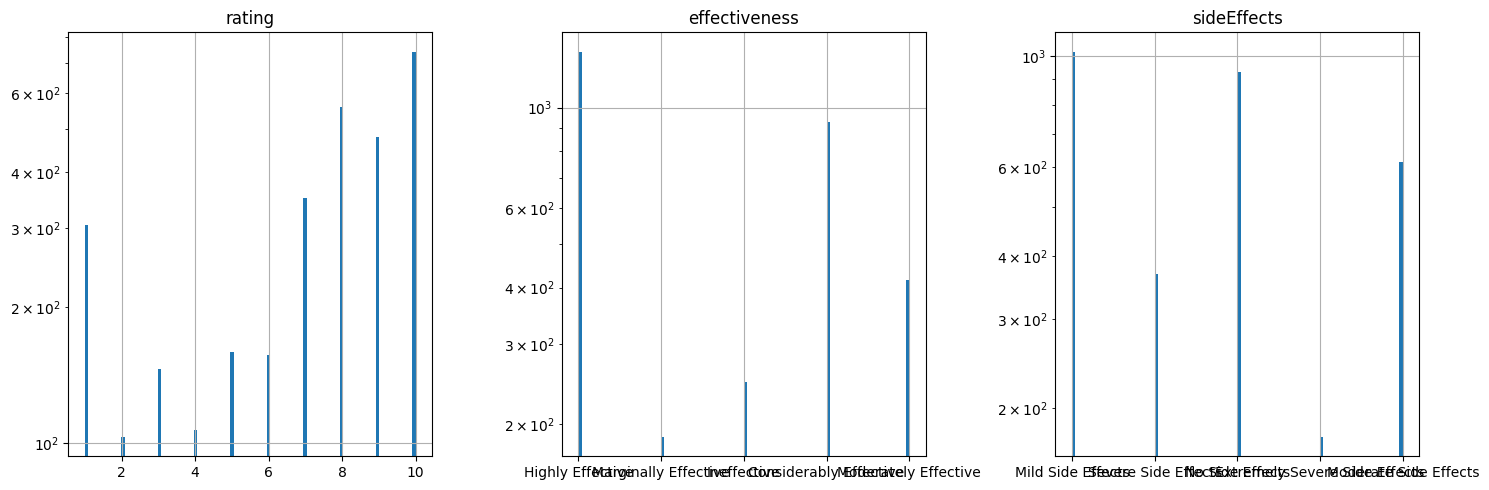

In [10]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(15, 5))

for n, c in enumerate(df_graficas.columns):

    ax = figure.add_subplot(1, 3, n + 1)

    ax.set_title(c)
    ax.set_yscale("log")

    df_graficas[c].hist(ax=ax, bins=100)

figure.tight_layout()
plt.show()

#### Transforma las columnas categoricas

Transforma las columnas categóricas no codificadas a numéricas mediante dummies.

In [11]:
# ojo, las columnas categóricas no codificadas ya


df_kmeans = pd.get_dummies(df_graficas, drop_first=True)

df_kmeans.head()

,rating,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
0,4,True,False,False,False,True,False,False,False
1,1,True,False,False,False,False,False,False,True
2,10,True,False,False,False,False,False,True,False
3,3,False,False,True,False,True,False,False,False
4,2,False,False,True,False,False,False,False,True


#### Evalúa cuál es la mejor K

Utiliza silhouette_score para evaluar cuál es la mejor K. Evalúa como mucho K = 20

#### Genera el K Means 

In [17]:
# usa el KMeans y el score de silueta
# ajusta el kmeans con k entre 1 y 20

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

modelos = []

for k in range(2, 20):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(df_kmeans)

    modelos.append(modelo)

In [18]:

# calcula los scores de silueta para cada modelo

scores = []

for modelo in modelos:

    if len(set(modelo.labels_)) > 1:

        score = silhouette_score(df_kmeans, modelo.labels_)

        scores.append(score)
scores

[0.6201588218717601,
 0.45783181456399225,
 0.41810334207684263,
 0.3656385189091405,
 0.3907211219762384,
 0.40177112287139927,
 0.43388813127553294,
 0.4281053584494092,
 0.4495480246307795,
 0.42731671124249593,
 0.4749363534938966,
 0.47219331041009877,
 0.47535988460746303,
 0.477553466147356,
 0.48491304211264646,
 0.518945550920418,
 0.5318471267844648,
 0.5534924891847787]

Text(0.5, 1.0, 'Evaluación de K')

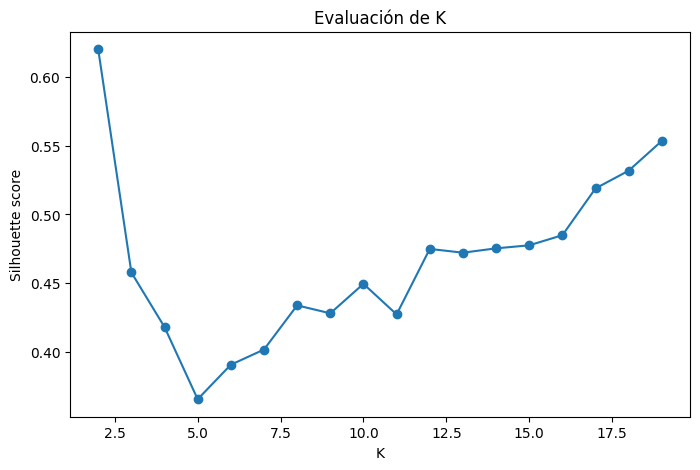

In [19]:
# pinta los scores de silueta para cada k


plt.figure(figsize=(8,5))

plt.plot(range(2,20), scores, marker="o")

plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Evaluación de K")


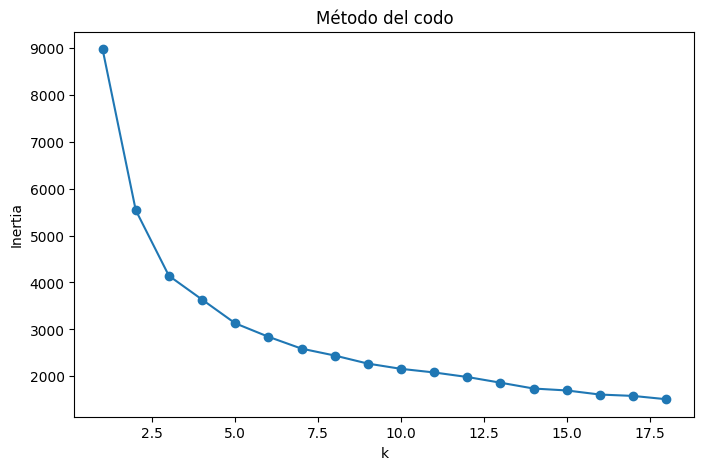

In [22]:
# pinta las inercias para cada k

inercias = []

for modelo in modelos:
    inercias.append(modelo.inertia_)

ks = range(1, len(inercias) + 1)

plt.figure(figsize=(8,5))

plt.plot(ks, inercias, marker="o")

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método del codo")

plt.show()

In [23]:
# entrena un kmeans con el valor de k óptimo seleccionado

kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_final.fit(df_kmeans)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


#### Muestra en un gráfico de quesito la distribución de los distintos clusters

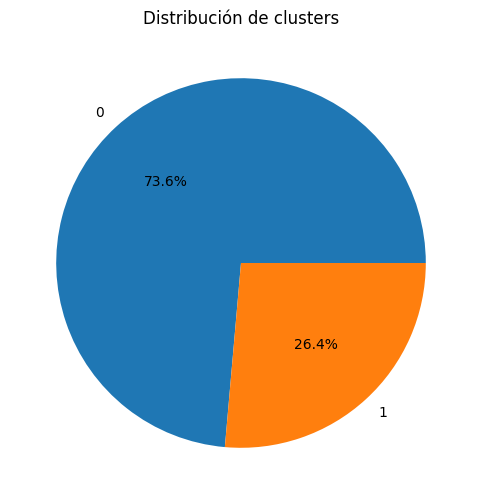

In [24]:


# a partir del kmeans calculado, muestra la proporción de clusters en un diagrama de quesito

clusters = pd.Series(kmeans_final.labels_)

clusters.value_counts().plot.pie(
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Distribución de clusters")
plt.ylabel("")

plt.show()
